In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
# Load the raw data
train_df = pd.read_csv('../data/raw/train.csv', low_memory=False)
store_df = pd.read_csv('../data/raw/store.csv')

In [6]:
# 1. Check the shape and basic info
print(f"Train Shape: {train_df.shape}")
print(train_df.info())

Train Shape: (1017209, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB
None


In [7]:
# 2. Look for missing values
print("\nMissing Values in Train Data:")
print(train_df.isnull().sum())


Missing Values in Train Data:
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


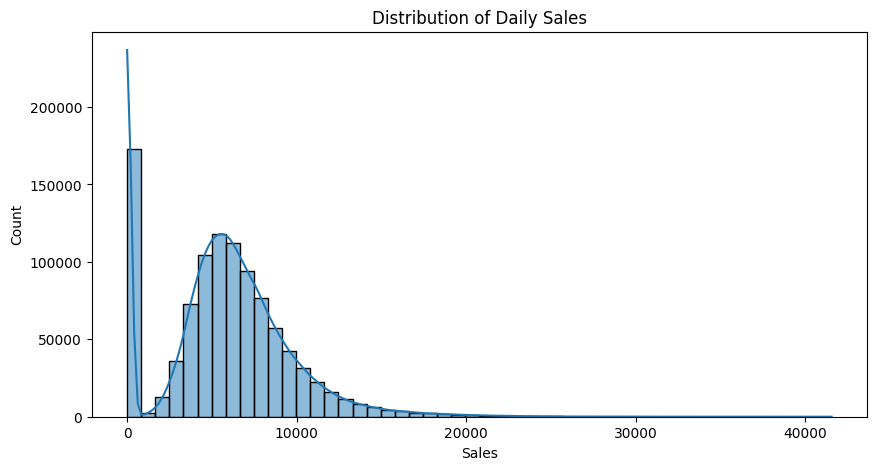

In [8]:
# 3. Visualize the target variable (Sales)
plt.figure(figsize=(10, 5))
sns.histplot(train_df['Sales'], bins=50, kde=True)
plt.title('Distribution of Daily Sales')
plt.show()

In [9]:
# 4. Check sales over time (using just one store to keep it readable)
store_1 = train_df[train_df['Store'] == 1].copy()
store_1['Date'] = pd.to_datetime(store_1['Date'])
store_1.sort_values('Date', inplace=True)

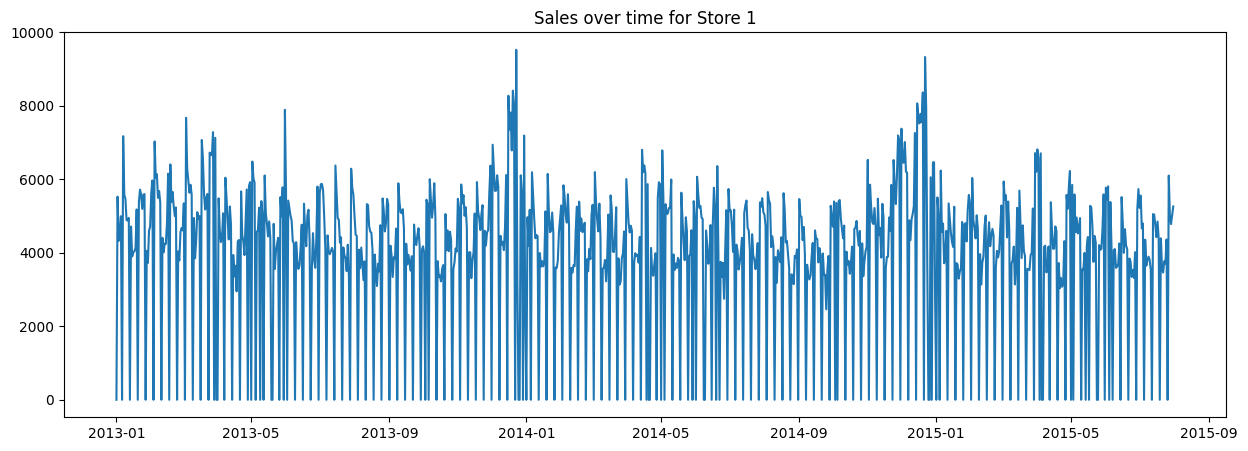

In [10]:
plt.figure(figsize=(15, 5))
plt.plot(store_1['Date'], store_1['Sales'])
plt.title('Sales over time for Store 1')
plt.show()


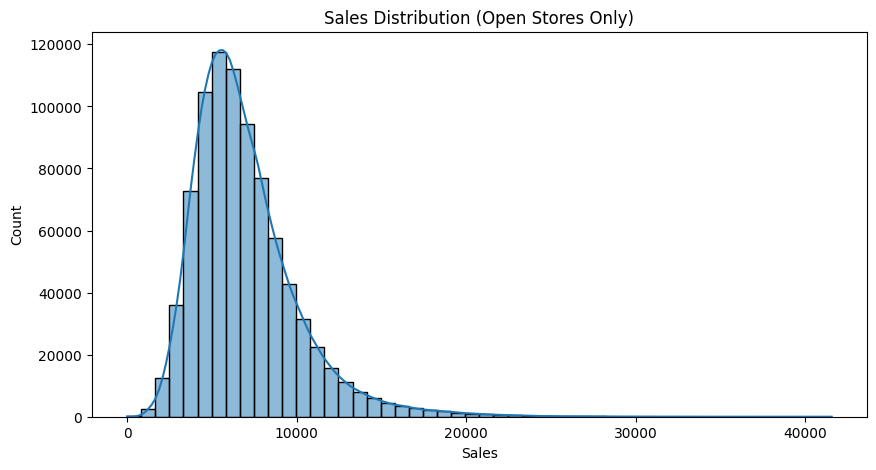

In [11]:
open_sales = train_df[train_df['Open'] == 1]

plt.figure(figsize=(10,5))
sns.histplot(open_sales['Sales'], bins=50, kde=True)
plt.title('Sales Distribution (Open Stores Only)')
plt.show()

In [12]:
# master dataset for all future work
df = (
    train_df
    .merge(store_df, on='Store', how='left')
    .sort_values(['Store', 'Date'])
    .reset_index(drop=True)
)

print(df.shape)
print(df.columns.tolist())

(1017209, 18)
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [13]:
print(df.shape)

(1017209, 18)


In [14]:
df.columns.tolist()

['Store',
 'DayOfWeek',
 'Date',
 'Sales',
 'Customers',
 'Open',
 'Promo',
 'StateHoliday',
 'SchoolHoliday',
 'StoreType',
 'Assortment',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Promo2',
 'Promo2SinceWeek',
 'Promo2SinceYear',
 'PromoInterval']

In [15]:
df.head(3)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,2013-01-01,0,0,0,0,a,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
2,1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN


In [16]:
df_model = df[df['Open'] == 1].copy()

In [17]:
df_model['Date'] = pd.to_datetime(df_model['Date'])

# 3. Sort chronologically
df_model = df_model.sort_values(['Store', 'Date'])

# 4. Remove leakage column
df_model = df_model.drop(columns=['Customers'])

In [18]:

# 5. Basic date features
df_model['Year'] = df_model['Date'].dt.year
df_model['Month'] = df_model['Date'].dt.month
df_model['WeekOfYear'] = df_model['Date'].dt.isocalendar().week.astype(int)
df_model['Quarter'] = df_model['Date'].dt.quarter
df_model['IsWeekend'] = (df_model['DayOfWeek'] >= 6).astype(int)


In [19]:

print(df_model.shape)
print(df_model[['Date','Sales','Month','IsWeekend']].head())

(844392, 22)
        Date  Sales  Month  IsWeekend
1 2013-01-02   5530      1          0
2 2013-01-03   4327      1          0
3 2013-01-04   4486      1          0
4 2013-01-05   4997      1          1
6 2013-01-07   7176      1          0


In [20]:
# A
df_model.shape



(844392, 22)

In [21]:
# B
df_model['Date'].min(), df_model['Date'].max()


(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [22]:

# C
df_model[['Sales','Promo','StateHoliday','StoreType','Assortment']].describe(include='all')

,Sales,Promo,StateHoliday,StoreType,Assortment
count,844392.000000,844392.000000,844392,844392,844392
unique,NaN,NaN,4,4,3
top,NaN,NaN,0,a,a
freq,NaN,NaN,843482,457077,444909
mean,6955.514291,0.446352,NaN,NaN,NaN
std,3104.214680,0.497114,NaN,NaN,NaN
min,0.000000,0.000000,NaN,NaN,NaN
25%,4859.000000,0.000000,NaN,NaN,NaN
50%,6369.000000,0.000000,NaN,NaN,NaN
75%,8360.000000,1.000000,NaN,NaN,NaN


In [23]:
zero_open_sales = df_model[df_model['Sales'] == 0]

print('Zero-sales open rows:', len(zero_open_sales))
print('Percentage:', round(len(zero_open_sales)/len(df_model)*100, 4), '%')



Zero-sales open rows: 54
Percentage: 0.0064 %


In [24]:
zero_open_sales[['Store','Date','Sales','Open']].head()

,Store,Date,Sales,Open
22463,25,2014-02-12,0,1
22464,25,2014-02-13,0,1
25491,28,2014-09-02,0,1
25492,28,2014-09-03,0,1
25493,28,2014-09-04,0,1


In [25]:
promo_effect = (
    df_model.groupby('Promo')['Sales']
    .agg(['mean','median','count'])
)

print(promo_effect)

              mean  median   count
Promo                             
0      5929.407603  5459.0  467496
1      8228.281239  7649.0  376896


In [26]:
df_model['StateHoliday'].value_counts()

StateHoliday
0    843482
a       694
b       145
c        71
Name: count, dtype: int64

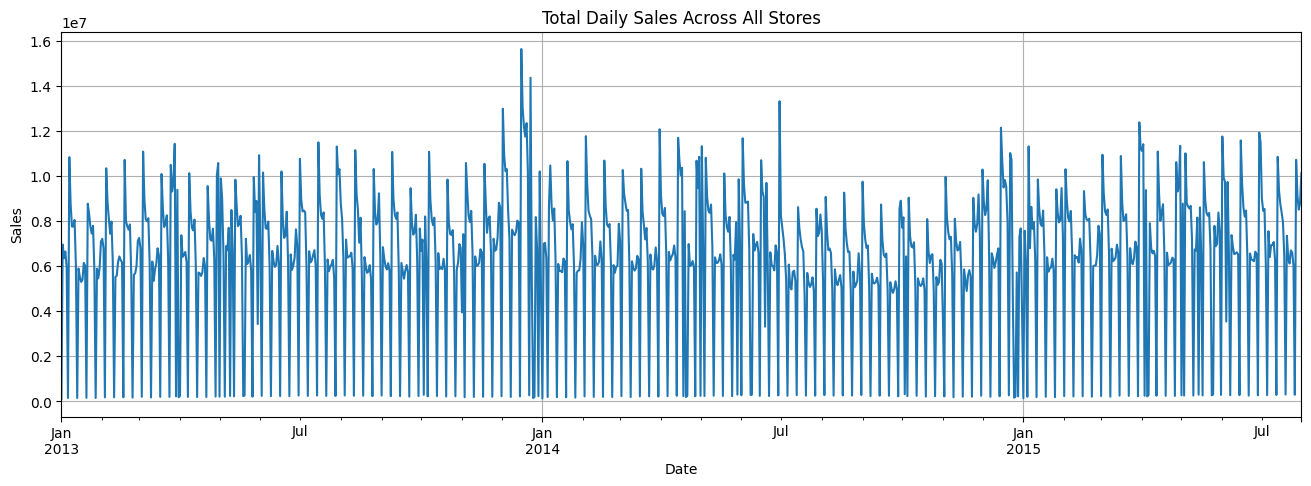

In [27]:
import matplotlib.pyplot as plt

daily_sales = (
    df_model.groupby('Date')['Sales']
    .sum()
)

plt.figure(figsize=(16,5))
daily_sales.plot()
plt.title('Total Daily Sales Across All Stores')
plt.ylabel('Sales')
plt.xlabel('Date')
plt.grid(True)
plt.show()

In [28]:
# 1. Zero-sales anomaly
len(df_model[df_model['Sales'] == 0])


54

In [29]:

# 2. Holiday distribution
df_model['StateHoliday'].value_counts()


StateHoliday
0    843482
a       694
b       145
c        71
Name: count, dtype: int64

In [30]:

# 3. Promotion uplift
df_model.groupby('Promo')['Sales'].agg(['mean','median','count'])

,mean,median,count
Promo,,,
0,5929.407603,5459.0,467496
1,8228.281239,7649.0,376896


In [31]:
df_model.head(3)


,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,WeekOfYear,Quarter,IsWeekend
1,1,3,2013-01-02,5530,1,0,0,1,c,a,...,2008.0,0,NaN,NaN,NaN,2013,1,1,1,0
2,1,4,2013-01-03,4327,1,0,0,1,c,a,...,2008.0,0,NaN,NaN,NaN,2013,1,1,1,0
3,1,5,2013-01-04,4486,1,0,0,1,c,a,...,2008.0,0,NaN,NaN,NaN,2013,1,1,1,0


In [32]:
# Start from our clean modeling dataset
df_feat = df_model.copy()

# Ensure correct order
df_feat = df_feat.sort_values(['Store', 'Date'])

# Create lag features per store
for lag in [1, 7, 14, 28]:
    df_feat[f'sales_lag_{lag}'] = (
        df_feat.groupby('Store')['Sales']
        .shift(lag)
    )

# Inspect
cols = ['Store', 'Date', 'Sales',
        'sales_lag_1', 'sales_lag_7',
        'sales_lag_14', 'sales_lag_28']

print(df_feat[cols].head(15))

    Store       Date  Sales  sales_lag_1  sales_lag_7  sales_lag_14  \
1       1 2013-01-02   5530          NaN          NaN           NaN   
2       1 2013-01-03   4327       5530.0          NaN           NaN   
3       1 2013-01-04   4486       4327.0          NaN           NaN   
4       1 2013-01-05   4997       4486.0          NaN           NaN   
6       1 2013-01-07   7176       4997.0          NaN           NaN   
7       1 2013-01-08   5580       7176.0          NaN           NaN   
8       1 2013-01-09   5471       5580.0          NaN           NaN   
9       1 2013-01-10   4892       5471.0       5530.0           NaN   
10      1 2013-01-11   4881       4892.0       4327.0           NaN   
11      1 2013-01-12   4952       4881.0       4486.0           NaN   
13      1 2013-01-14   4717       4952.0       4997.0           NaN   
14      1 2013-01-15   3900       4717.0       7176.0           NaN   
15      1 2013-01-16   4008       3900.0       5580.0           NaN   
16    

In [33]:
# Rolling averages
df_feat['rolling_mean_7'] = (
    df_feat.groupby('Store')['Sales']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

df_feat['rolling_mean_14'] = (
    df_feat.groupby('Store')['Sales']
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

# Rolling volatility
df_feat['rolling_std_7'] = (
    df_feat.groupby('Store')['Sales']
    .transform(lambda x: x.shift(1).rolling(7).std())
)

# Inspect
inspect_cols = [
    'Date', 'Sales',
    'sales_lag_1',
    'rolling_mean_7',
    'rolling_mean_14',
    'rolling_std_7'
]

print(df_feat[inspect_cols].head(20))

         Date  Sales  sales_lag_1  rolling_mean_7  rolling_mean_14  \
1  2013-01-02   5530          NaN             NaN              NaN   
2  2013-01-03   4327       5530.0             NaN              NaN   
3  2013-01-04   4486       4327.0             NaN              NaN   
4  2013-01-05   4997       4486.0             NaN              NaN   
6  2013-01-07   7176       4997.0             NaN              NaN   
7  2013-01-08   5580       7176.0             NaN              NaN   
8  2013-01-09   5471       5580.0             NaN              NaN   
9  2013-01-10   4892       5471.0     5366.714286              NaN   
10 2013-01-11   4881       4892.0     5275.571429              NaN   
11 2013-01-12   4952       4881.0     5354.714286              NaN   
13 2013-01-14   4717       4952.0     5421.285714              NaN   
14 2013-01-15   3900       4717.0     5381.285714              NaN   
15 2013-01-16   4008       3900.0     4913.285714              NaN   
16 2013-01-17   4044

In [34]:
# Remove rows without sufficient history
required_features = [
    'sales_lag_28',
    'rolling_mean_14'
]

df_final = df_feat.dropna(subset=required_features).copy()

print('Before:', df_feat.shape)
print('After :', df_final.shape)

Before: (844392, 29)
After : (813172, 29)


In [35]:


# A
df_final.shape


(813172, 29)

In [36]:

# B
df_final[['sales_lag_1','sales_lag_7',
          'rolling_mean_7','rolling_std_7']].head()


,sales_lag_1,sales_lag_7,rolling_mean_7,rolling_std_7
34,5970.0,5598.0,4898.714286,855.366727
35,7032.0,4055.0,5103.571429,1166.051436
36,6049.0,3725.0,5388.428571,1109.382990
37,6140.0,4601.0,5733.428571,851.378658
38,5499.0,4709.0,5861.714286,707.864797


In [37]:

# C
df_final[['Sales','sales_lag_7','rolling_mean_7']].corr()

,Sales,sales_lag_7,rolling_mean_7
Sales,1.000000,0.527687,0.736627
sales_lag_7,0.527687,1.000000,0.816545
rolling_mean_7,0.736627,0.816545,1.000000


In [38]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Directories
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Output file
output_path = PROCESSED_DIR / 'retail_features.parquet'

print('Saving to:', output_path)

# Save with FASTPARQUET
df_final.to_parquet(
    output_path,
    engine='fastparquet',
    index=False
)

print('Saved successfully!')
print('Rows:', len(df_final))

Saving to: /home/simbarashe/Desktop/PROJECTS/zimbabwe-retail-forecast/data/processed/retail_features.parquet
Saved successfully!
Rows: 813172


In [57]:
os.getcwd()

'/home/simbarashe/Desktop/PROJECTS/zimbabwe-retail-forecast/notebooks'

In [39]:
import pandas as pd

check_df = pd.read_parquet(output_path, engine='fastparquet')

print(check_df.shape)
print(check_df[['Date', 'Sales']].head())

(813172, 29)
        Date  Sales
0 2013-02-04   7032
1 2013-02-05   6049
2 2013-02-06   6140
3 2013-02-07   5499
4 2013-02-08   5681


In [ ]:
#inspect the parquet file
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
parquet_path = PROJECT_ROOT / 'data' / 'processed' / 'retail_features.parquet'

# Load it
df_check = pd.read_parquet(parquet_path, engine='fastparquet')

# Inspect
print(df_check.shape)
df_check.head()

(813172, 29)


,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,WeekOfYear,Quarter,IsWeekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7
0,1,1,2013-02-04,7032,1,1,0,0,c,a,...,6,1,0,5970.0,5598.0,4127.0,5530.0,4898.714286,5076.642857,855.366727
1,1,2,2013-02-05,6049,1,1,0,0,c,a,...,6,1,0,7032.0,4055.0,5182.0,4327.0,5103.571429,5284.142857,1166.051436
2,1,3,2013-02-06,6140,1,1,0,0,c,a,...,6,1,0,6049.0,3725.0,5394.0,4486.0,5388.428571,5346.071429,1109.382990
3,1,4,2013-02-07,5499,1,1,0,0,c,a,...,6,1,0,6140.0,4601.0,5720.0,4997.0,5733.428571,5399.357143,851.378658
4,1,5,2013-02-08,5681,1,1,0,0,c,a,...,6,1,0,5499.0,4709.0,5578.0,7176.0,5861.714286,5383.571429,707.864797


In [ ]:
#check if the parquet file exists
parquet_path.exists(), parquet_path

(True,
 PosixPath('/home/simbarashe/Desktop/PROJECTS/zimbabwe-retail-forecast/data/processed/retail_features.parquet'))